# **NAATOS LFA DATA ANALYSIS**<br>
for more details see: [Github](https://github.com/Global-Health-Labs/LFA_GUI.git)
#### **Tips and Instructions**
- click the little ▶ play icon to the left of each cell below.


In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML, Image, Markdown, Javascript
import cv2
import numpy as np
import os
from scipy.signal import savgol_filter, find_peaks
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PiImage
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio


# Create text widget for output
output_text = widgets.Text()

# Create text widget for input
input_text = widgets.Text(
placeholder='Enter the path to mp4 file',
description='String:',
disabled=False,
continuous_update=False)

# Define function to bind value of the input to the output variable 
def bind_input_to_output(sender):
    output_text.value = input_text.value

# Tell the text input widget to call bind_input_to_output() on submit
input_text.observe(bind_input_to_output,'value')

# Display input text box widget for input
display(input_text)

Text(value='', continuous_update=False, description='String:', placeholder='Enter the path to mp4 file')

In [2]:
# Display text value of string in output_text variable
output_text.value

'SG3_VideoAnalysis/Dilution_1/SG3 Arm 1 Dilution 1 - 009-016.mp4'

Analysis complete. Results are saved in the output directory.


,Unnamed: 0,1,2,3,4,5,6,7,8
0,green FC peak index,20.000000,23.000000,24.000000,24.000000,19.000000,16.000000,18.000000,16.000000
1,green IPC peak index,52.000000,55.000000,55.000000,56.000000,50.000000,48.000000,50.000000,47.000000
2,green TB peak index,86.000000,0.000000,0.000000,87.000000,82.000000,84.000000,85.000000,0.000000
3,green FC peak signal,147.742964,148.860896,154.915909,140.854442,145.608581,152.525475,148.137675,149.992596
4,green IPC peak signal,107.207232,105.241731,100.602448,102.268842,105.528067,109.183616,110.103147,111.000206
5,green TB peak signal,88.165444,-inf,-inf,83.978503,77.719713,76.182418,78.114948,-inf
6,green background mean,73.125106,70.180512,69.778912,67.278237,67.636340,69.398563,70.639182,73.704648
7,green background std,2.262260,2.757363,3.668755,4.304412,4.084345,4.708523,3.313784,3.009375
8,LOD Threshold,79.911887,78.452602,80.785179,80.191472,79.889376,83.524132,80.580536,82.732773


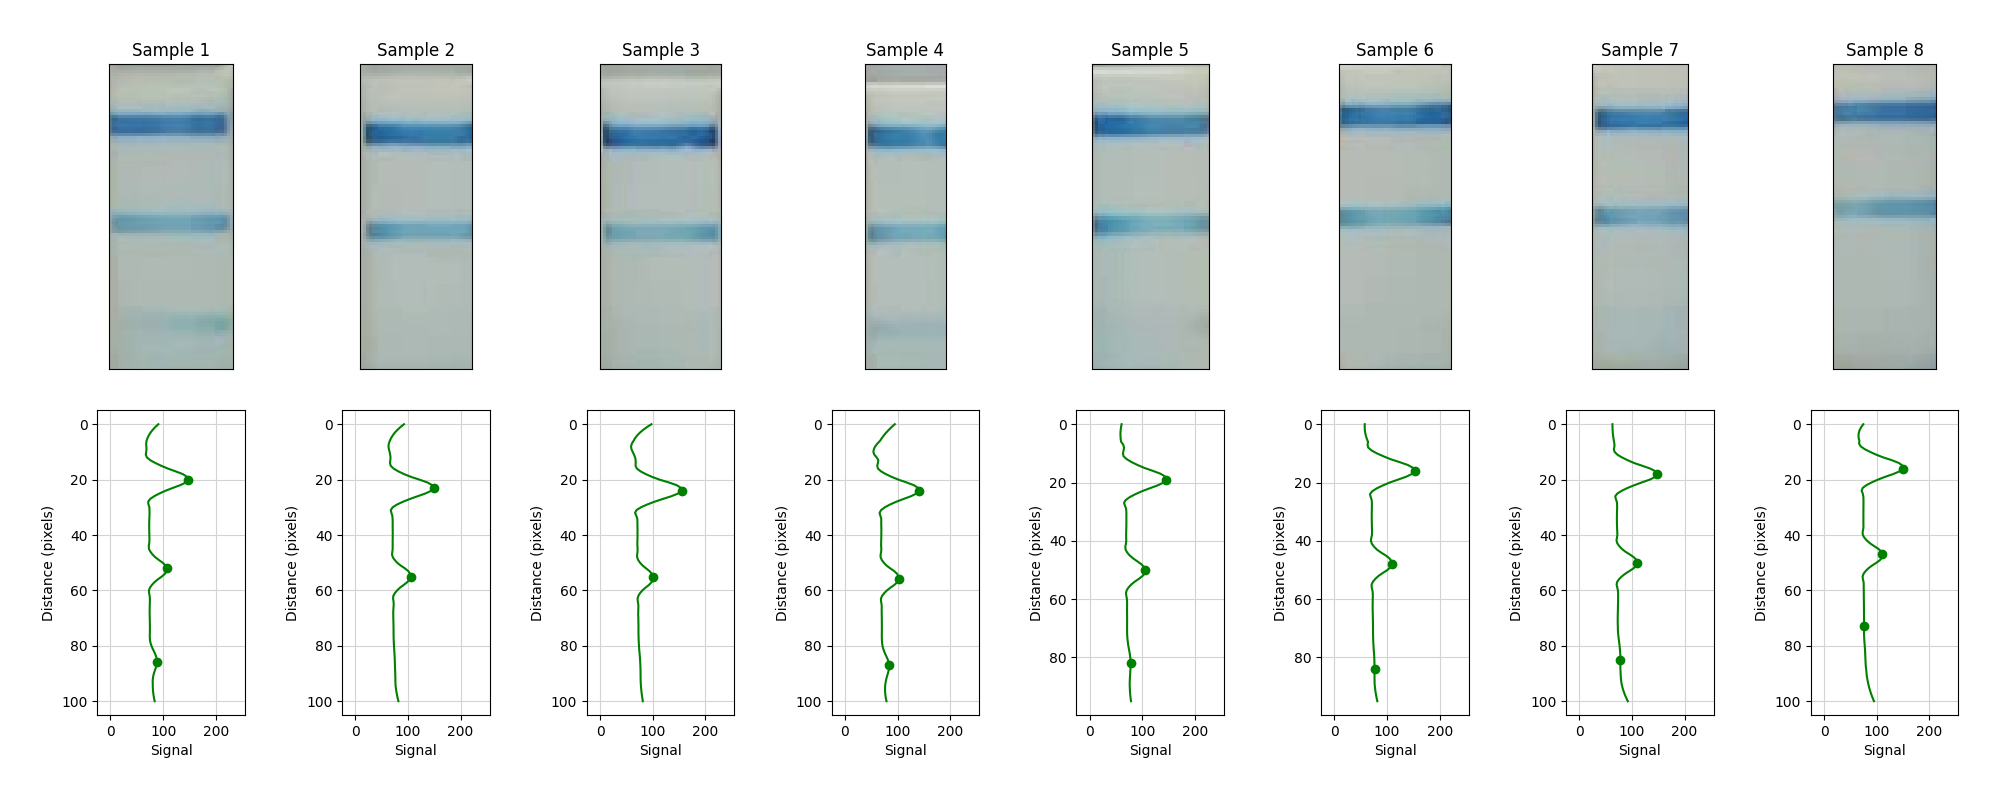

In [3]:
try:
    class VideoAnalyzer:
        def __init__(self, video_file):
            self.video_file = video_file
            self.cap = cv2.VideoCapture(video_file)
            self.fps = self.cap.get(cv2.CAP_PROP_FPS)
            
            if self.fps <= 0:
                raise ValueError("Failed to read the video file or the video has zero fps.")
            
            self.new_dir = os.path.splitext(video_file)[0]
            os.makedirs(self.new_dir, exist_ok=True)
            
            self._extract_median_frame()
            
        def _extract_median_frame(self):
            num_frames_in_30_seconds = int(self.fps * 30)
            frame_ids = np.random.choice(num_frames_in_30_seconds, size=25, replace=False)
            frames = [self._read_frame(fid) for fid in frame_ids if self._read_frame(fid) is not None]
            self.median_frame = np.median(frames, axis=0).astype(dtype=np.uint8)

        def _read_frame(self, fid):
            self.cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
            ret, frame = self.cap.read()
            return frame if ret else None

        def generate_difference_video(self):
            output_video_path = os.path.join(self.new_dir, 'output.avi')
            out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'XVID'), 20.0,
                                (int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))), True)
            all_frames = []
            while True:
                ret, frame = self.cap.read()
                if not ret:
                    break
                dframe = cv2.absdiff(frame, self.median_frame)
                out.write(dframe)
                all_frames.append(dframe)
                self.last_frame = frame
            self.all_frames = all_frames
            self.cap.release()
            out.release()
            self._save_last_frame()
        
        def _save_last_frame(self):
            if self.last_frame is not None:
                last_frame_pic = os.path.join(self.new_dir, 'last_frame.jpg')
                cv2.imwrite(last_frame_pic, self.last_frame)

        def analyze_frames(self):
            rois = [
                ((75, 304), (130, 405)),
                ((330, 304), (380, 405)),
                ((574, 304), (624, 405)),
                ((825, 304), (870, 405)),
                ((1065, 309), (1105, 405)),
                ((1310, 309), (1350, 405)),
                ((1560, 304), (1600, 405)),
                ((1805, 304), (1845, 405)),
            ]
            
            data_points = []
            lod_thresholds_B_last = [None] * len(rois)
            lod_thresholds_G_last = [None] * len(rois)
            lod_thresholds_R_last = [None] * len(rois)

            # First loop to collect data and determine the LOD thresholds for the last frame
            for frame_idx, frame in enumerate(self.all_frames):
                time_in_seconds = frame_idx / self.fps
                for i, (roi_start, roi_end) in enumerate(rois):
                    x_start, y_start = roi_start
                    x_end, y_end = roi_end
                    roi = frame[y_start:y_end, x_start:x_end]

                    # Calculate the mean pixel intensity along the vertical axis for BGR channels
                    line_profile_B = np.mean(roi[:, :, 0], axis=1)
                    line_profile_G = np.mean(roi[:, :, 1], axis=1)
                    line_profile_R = np.mean(roi[:, :, 2], axis=1)

                    # Find peaks in the line profile
                    filtered_B, peaks_X_B, peaks_Y_B, lod_threshold_B = self._find_lfa_peaks(line_profile_B, top=y_start)
                    filtered_G, peaks_X_G, peaks_Y_G, lod_threshold_G = self._find_lfa_peaks(line_profile_G, top=y_start)
                    filtered_R, peaks_X_R, peaks_Y_R, lod_threshold_R = self._find_lfa_peaks(line_profile_R, top=y_start)

                    # Update LOD thresholds for the last frame
                    if frame_idx == len(self.all_frames) - 1:
                        lod_thresholds_B_last[i] = lod_threshold_B
                        lod_thresholds_G_last[i] = lod_threshold_G
                        lod_thresholds_R_last[i] = lod_threshold_R

                    # Collect data points (initially without LOD thresholds)
                    for y in range(len(filtered_B)):
                        data_points.append({
                            'Time (s)': time_in_seconds,
                            'Rectangle': i + 1,
                            'Pixel': 100 - y,  # Invert pixel values
                            'Blue': filtered_B[y],
                            'Green': filtered_G[y],
                            'Red': filtered_R[y]
                        })

            # Second loop to apply the last frame's LOD thresholds to all data points
            for point in data_points:
                rectangle_idx = point['Rectangle'] - 1
                point['LOD_trshld_Blue'] = lod_thresholds_B_last[rectangle_idx]
                point['LOD_trshld_Green'] = lod_thresholds_G_last[rectangle_idx]
                point['LOD_trshld_Red'] = lod_thresholds_R_last[rectangle_idx]

            df = pd.DataFrame(data_points)
            csv_file_path = os.path.join(self.new_dir, 'data_points.csv')
            df.to_csv(csv_file_path, index=False)

        def _find_lfa_peaks(self, line_profile, top=0):
            filtered = savgol_filter(line_profile, 3, 2)
            lowest_length = np.clip(len(filtered) // 2, 1, 50) - 1
            lowest = np.sort(filtered)[:lowest_length]
            background = np.mean(lowest)
            background_std = np.std(lowest)
            lod_threshold = background + 3 * background_std
            peaks_x, _ = find_peaks(filtered)
            peaks_y = filtered[peaks_x]

            line_vals = [top + 25, top + 50, top + 80]
            interval_vals = [20, 20, 20]

            x_intervals = [[int(line - interval - top), int(line + interval - top)] for line, interval in zip(line_vals, interval_vals)]
            peaks_xy_max = [max([[x, y] for x, y in zip(peaks_x, peaks_y) if a <= x <= b], key=lambda xy: xy[1], default=[None, None]) for a, b in x_intervals]
            peaks_xy_max.append([None, background])

            peaks_x_by_location, peaks_y_by_location = zip(*peaks_xy_max)
            return filtered, list(peaks_x_by_location), list(peaks_y_by_location), lod_threshold


                
    class ImageAnalyzer:
        def __init__(self, video_file, output_dir, n_lines=3, color_channels=['green']):
            self.video_file = video_file
            self.cap = cv2.VideoCapture(video_file)
            self.n_lines = n_lines
            self.color_channels = color_channels
            self.df = pd.DataFrame()

            # Extract directory path from video path
            self.output_dir = output_dir

            # Define the parameters
            self.rois = [
                ((75, 304), (130, 400)),
                ((330, 304), (380, 400)),
                ((574, 304), (624, 400)),
                ((825, 304), (870, 400)),
                ((1065, 309), (1105, 400)),
                ((1310, 309), (1350, 400)),
                ((1560, 304), (1600, 400)),
                ((1805, 304), (1845, 400)),
            ]
            self.line_positions = [329, 359, 389]
            self.intervals = [10, 10, 10]
            self.sample_label = 'sample'
            self.y_start = 304 #309

        def analyze(self):
            frame_count = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
            num_rois = len(self.rois)

            for frame_number in range(frame_count):
                ret, frame = self.cap.read()
                if not ret:
                    break
                
                frame_img = PiImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

                # Calculate timestamp
                timestamp = frame_number / self.cap.get(cv2.CAP_PROP_FPS)

                for count, (start, end) in enumerate(self.rois):
                    self._process_roi(frame_img, start, end, self.line_positions, self.intervals, self.sample_label, count, timestamp, self.y_start)

            self.cap.release()

            # Save dataframe and generate plotly graph
            output_path = os.path.join(self.output_dir, 'imageanalyzer_output_data.csv')
            self.save_dataframe(output_path)
            output_html = os.path.join(self.output_dir, 'FC_IPC_TB_graph.html')
            self.generate_plotly_graph(output_path, output_html)

        def _process_roi(self, frame_img, start, end, line_positions, intervals, sample_label, count, timestamp, y_start):
            left, top = start
            right, bottom = end

            roi = frame_img.crop((left, top, right, bottom))
            roi_gray = roi.convert('L')
            nleft, nright = self._calculate_lr_border(roi_gray)
            roi_tight_gray = roi_gray.crop((nleft, 0, nright, roi.size[1]))
            roi_tight_color = roi.crop((nleft, 0, nright, roi.size[1]))

            roi_green = roi_tight_color.split()[1]
            channel_line = 255 - np.mean(np.asarray(roi_green), axis=1)
            line_peak = self._find_lfa_peaks(channel_line, top)

            self._save_data(line_peak, sample_label, count + 1, timestamp, line_positions, intervals, y_start)


        def _calculate_lr_border(self, image):
            arr = np.asarray(image)
            mean_vertical = np.mean(arr, axis=0)
            gradient = np.gradient(mean_vertical)
            halfpoint = gradient.size // 2
            left = np.argmin(gradient[:halfpoint])
            right = np.argmin(gradient[halfpoint:]) + halfpoint
            return left, right

        def _find_lfa_peaks(self, line_profile, top):
            filtered = savgol_filter(line_profile, 13, 2)
            lowest_length = np.clip(len(filtered) // 2, 1, 50) - 1
            lowest = np.sort(filtered)[:lowest_length]
            background = np.mean(lowest)

            peaks_x, _ = find_peaks(filtered)
            peaks_y = filtered[peaks_x]

            return filtered, list(peaks_x), list(peaks_y), background

        def _save_data(self, line_peak, sample_label, roi_number, timestamp, line_positions, intervals, y_start):
            peaks_indices = line_peak[1]
            peaks_signals = line_peak[2]

            # Adjust the line_positions using y_start
            adjusted_line_positions = [pos - y_start for pos in line_positions]

            # Define the boundaries for FC, IPC, and TB using adjusted_line_positions and intervals
            fc_range = range(adjusted_line_positions[0] - intervals[0], adjusted_line_positions[0] + intervals[0] - 1)
            ipc_range = range(adjusted_line_positions[1] - intervals[1], adjusted_line_positions[1] + intervals[1] - 1)
            tb_range = range(adjusted_line_positions[2] - intervals[2], adjusted_line_positions[2] + intervals[2] + 2)

            # Initialize variables to store peak information
            fc_peak_index, ipc_peak_index, tb_peak_index = None, None, None
            fc_peak_signal, ipc_peak_signal, tb_peak_signal = None, None, None

            # Function to find the peak with the maximum signal in a given range
            def find_max_peak_in_range(range_vals):
                max_signal = -float('inf')
                max_index = None
                for idx, peak_idx in enumerate(peaks_indices):
                    if peak_idx in range_vals and peaks_signals[idx] > max_signal:
                        max_signal = peaks_signals[idx]
                        max_index = peak_idx
                return max_index, max_signal

            # Find the peak with the maximum signal in each range
            fc_peak_index, fc_peak_signal = find_max_peak_in_range(fc_range)
            ipc_peak_index, ipc_peak_signal = find_max_peak_in_range(ipc_range)
            tb_peak_index, tb_peak_signal = find_max_peak_in_range(tb_range)

            # Calculate background signal
            background_signal = line_peak[3]

            # Subtract background from peak signals and ensure non-negative values
            # fc_peak_signal = max((fc_peak_signal if fc_peak_signal is not None else 0) - background_signal, 0)
            # ipc_peak_signal = max((ipc_peak_signal if ipc_peak_signal is not None else 0) - background_signal, 0)
            # tb_peak_signal = max((tb_peak_signal if tb_peak_signal is not None else 0) - background_signal, 0)

            # Fill empty values with 0
            data = {
                'selection': roi_number,
                'timestamp': timestamp,
                'green FC peak index': fc_peak_index if fc_peak_index is not None else 0,
                'green IPC peak index': ipc_peak_index if ipc_peak_index is not None else 0,
                'green TB peak index': tb_peak_index if tb_peak_index is not None else 0,
                'green FC peak signal': fc_peak_signal,
                'green IPC peak signal': ipc_peak_signal,
                'green TB peak signal': tb_peak_signal,
                'green background signal': background_signal
            }

            new_df = pd.DataFrame(data, index=[0])
            self.df = pd.concat([self.df, new_df], ignore_index=True)

        def save_dataframe(self, output_path):
            # Save DataFrame without transposing
            self.df.to_csv(output_path, index=False)

        def generate_plotly_graph(self, csv_path, output_html):
            data = pd.read_csv(csv_path)

            fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                                subplot_titles=('Green FC Peak Signal', 'Green IPC Peak Signal', 'Green TB Peak Signal'))

            selections = data['selection'].unique()
            trace_dict = {'green FC peak signal': [], 'green IPC peak signal': [], 'green TB peak signal': []}

            for sel in selections:
                sel_data = data[data['selection'] == sel]
                trace_dict['green FC peak signal'].append(go.Scatter(x=sel_data['timestamp'], y=sel_data['green FC peak signal'], mode='lines+markers', name=f'Green FC Peak Signal (Selection {sel})', visible=True if sel == selections[0] else False))
                trace_dict['green IPC peak signal'].append(go.Scatter(x=sel_data['timestamp'], y=sel_data['green IPC peak signal'], mode='lines+markers', name=f'Green IPC Peak Signal (Selection {sel})', visible=True if sel == selections[0] else False))
                trace_dict['green TB peak signal'].append(go.Scatter(x=sel_data['timestamp'], y=sel_data['green TB peak signal'], mode='lines+markers', name=f'Green TB Peak Signal (Selection {sel})', visible=True if sel == selections[0] else False))

            for trace in trace_dict['green FC peak signal']:
                fig.add_trace(trace, row=1, col=1)

            for trace in trace_dict['green IPC peak signal']:
                fig.add_trace(trace, row=2, col=1)

            for trace in trace_dict['green TB peak signal']:
                fig.add_trace(trace, row=3, col=1)

            fig.update_xaxes(title_text='Time (s)', row=3, col=1)
            fig.update_yaxes(title_text='Intensity', row=1, col=1)
            fig.update_yaxes(title_text='Intensity', row=2, col=1)
            fig.update_yaxes(title_text='Intensity', row=3, col=1)

            buttons = []
            for sel in selections:
                buttons.append(dict(
                    method='update',
                    label=f'Selection {sel}',
                    args=[{'visible': [trace.name.endswith(f'(Selection {sel})') for trace in fig.data]},
                        {'title': f'Signal Intensity Over Time - Selection {sel}'}]
                ))

            fig.update_layout(
                updatemenus=[dict(
                    active=0,
                    buttons=buttons,
                    x=1.1,
                    y=1.15,
                    xanchor='right',
                    yanchor='top'
                )],
                height=900,
                width=1200,
                title_text='Peak Signal Intensity Over Time'
            )

            pio.write_html(fig, file=output_html, auto_open=False)

    
    class LastFrameAnalyzer:
        def __init__(self, img_path, n_lines=3, color_channels=['green']):
            self.img_path = img_path
            self.img = PiImage.open(img_path)
            self.n_lines = n_lines
            self.color_channels = color_channels
            self.df = pd.DataFrame()

            # Define the ROIs, line positions, intervals, and sample label here
            self.rois = [
                ((75, 304), (120, 405)),
                ((330, 304), (370, 405)),
                ((574, 304), (624, 405)),
                ((825, 304), (870, 405)),
                ((1065, 309), (1105, 405)),
                ((1310, 309), (1350, 405)),
                ((1560, 304), (1600, 405)),
                ((1805, 304), (1845, 405)),
            ]
            self.line_positions = [329, 359, 389]
            self.intervals = [15, 15, 10]
            self.sample_label = 'sample'
            self.y_start = 304 #309

            # Extract directory path from image path
            self.output_dir = os.path.dirname(img_path)

        def analyze(self):
            num_rois = len(self.rois)
            fig, axes = plt.subplots(nrows=2, ncols=num_rois, figsize=(2.5 * num_rois, 8))

            for count, (start, end) in enumerate(self.rois):
                self._process_roi(start, end, count, axes[0, count], axes[1, count])

            for count in range(num_rois):
                axes[0, count].set_title(f'Sample {count + 1}')
                axes[1, count].set_ylabel('Distance (pixels)')

            plt.tight_layout(pad=3.0)
            plt.savefig(os.path.join(self.output_dir, 'output.png'))
            plt.close(fig)
            
            self.save_dataframe(os.path.join(self.output_dir, 'image_data.csv'))

        def _process_roi(self, start, end, count, ax_img, ax_plot):
            left, top = start
            right, bottom = end

            roi = self.img.crop((left, top, right, bottom))
            roi_gray = roi.convert('L')
            nleft, nright = self._calculate_lr_border(roi_gray)
            roi_tight_gray = roi_gray.crop((nleft, 0, nright, roi.size[1]))
            roi_tight_color = roi.crop((nleft, 0, nright, roi.size[1]))

            channel_lines = [255 - np.mean(np.asarray(roi_channel), axis=1) for roi_channel in [roi_tight_gray] + list(roi_tight_color.split())]
            line_peaks = [self._find_lfa_peaks(channel_lines[i], top) for i in range(len(self.color_channels))]

            self._save_plots(roi_tight_color, line_peaks, ax_img, ax_plot)
            self._save_data(line_peaks, count + 1)

        def _calculate_lr_border(self, image):
            arr = np.asarray(image)
            mean_vertical = np.mean(arr, axis=0)
            gradient = np.gradient(mean_vertical)
            halfpoint = gradient.size // 2
            left = np.argmin(gradient[:halfpoint])
            right = np.argmin(gradient[halfpoint:]) + halfpoint
            return left, right

        def _find_lfa_peaks(self, line_profile, top):
            filtered = savgol_filter(line_profile, 13, 2)
            lowest_length = np.clip(len(filtered) // 2, 1, 50) - 1
            lowest = np.sort(filtered)[:lowest_length]
            background = np.mean(lowest)
            peaks_x, _ = find_peaks(filtered, distance=20)
            peaks_y = filtered[peaks_x]
            background_std = np.std(lowest)
            lod_threshold = background + 3 * background_std

            return filtered, list(peaks_x), list(peaks_y), background, background_std, lod_threshold

        def _save_plots(self, roi_tight_color, line_peaks, ax_img, ax_plot):
            ax_img.imshow(roi_tight_color, aspect='equal')
            ax_img.set_xticks([])
            ax_img.set_yticks([])

            for i, (filtered, peaks_x, peaks_y, background, background_std, lod_threshold) in enumerate(line_peaks):
                ax_plot.plot(filtered, range(len(filtered)), color=self.color_channels[i])
                ax_plot.plot(peaks_y, peaks_x, 'o', color=self.color_channels[i])

            ax_plot.set(xlabel='Signal', xlim=[-25, 255], xticks=[0, 100, 200])
            ax_plot.grid(True, which='major', color='lightgray')
            ax_plot.invert_yaxis()

        def _save_data(self, line_peaks, roi_number):
            data = {'selection': roi_number}
            for i, color_channel in enumerate(self.color_channels):
                peaks_indices = line_peaks[i][1]
                peaks_signals = line_peaks[i][2]
                background_mean = line_peaks[i][3]
                background_std = line_peaks[i][4]
                lod_threshold = line_peaks[i][5]

                # Adjust the line positions using y_start
                adjusted_line_positions = [pos - self.y_start for pos in self.line_positions]

                # Define the boundaries for FC, IPC, and TB using adjusted line positions and intervals
                fc_range = range(adjusted_line_positions[0] - self.intervals[0], adjusted_line_positions[0] + self.intervals[0] - 1)
                ipc_range = range(adjusted_line_positions[1] - self.intervals[1], adjusted_line_positions[1] + self.intervals[1] - 1)
                tb_range = range(adjusted_line_positions[2] - self.intervals[2], adjusted_line_positions[2] + self.intervals[2] -1)

                # Function to find the peak with the maximum signal in a given range
                def find_max_peak_in_range(range_vals):
                    max_signal = -float('inf')
                    max_index = None
                    for idx, peak_idx in enumerate(peaks_indices):
                        if peak_idx in range_vals and peaks_signals[idx] > max_signal:
                            max_signal = peaks_signals[idx]
                            max_index = peak_idx
                    return max_index, max_signal

                # Find the peak with the maximum signal in each range
                fc_peak_index, fc_peak_signal = find_max_peak_in_range(fc_range)
                ipc_peak_index, ipc_peak_signal = find_max_peak_in_range(ipc_range)
                tb_peak_index, tb_peak_signal = find_max_peak_in_range(tb_range)

                # Subtract background from peak signals and ensure non-negative values
                # fc_peak_signal = max((fc_peak_signal if fc_peak_signal is not None else 0) - background_mean, 0)
                # ipc_peak_signal = max((ipc_peak_signal if ipc_peak_signal is not None else 0) - background_mean, 0)
                # tb_peak_signal = max((tb_peak_signal if tb_peak_signal is not None else 0) - background_mean, 0)

                # Extract the filename without extension
                file_name_without_ext = os.path.splitext(os.path.basename(self.img_path))[0]

                # Fill empty values with 0 and compile data
                data = {
                    'selection': file_name_without_ext,
                    f'{color_channel} FC peak index': fc_peak_index if fc_peak_index is not None else 0,
                    f'{color_channel} IPC peak index': ipc_peak_index if ipc_peak_index is not None else 0,
                    f'{color_channel} TB peak index': tb_peak_index if tb_peak_index is not None else 0,
                    f'{color_channel} FC peak signal': fc_peak_signal,
                    f'{color_channel} IPC peak signal': ipc_peak_signal,
                    f'{color_channel} TB peak signal': tb_peak_signal,
                    f'{color_channel} background mean': background_mean,
                    f'{color_channel} background std': background_std,
                    'LOD Threshold': lod_threshold
                }

                new_df = pd.DataFrame(data, index=[0])
                self.df = pd.concat([self.df, new_df], ignore_index=True)

        def save_dataframe(self, output_path):
            self.df = self.df.set_index('selection').transpose()
            self.df.columns = range(1, len(self.df.columns) + 1)
            self.df.to_csv(output_path, index=True)

        def run_analysis(self):
            self.analyze()

        
    video_analyzer = VideoAnalyzer(output_text.value)
    video_analyzer.generate_difference_video()
    video_analyzer.analyze_frames()

    image_analyzer = ImageAnalyzer(output_text.value, output_dir=video_analyzer.new_dir)
    image_analyzer.analyze()

    img_path = os.path.join(video_analyzer.new_dir, 'last_frame.jpg')
    if os.path.exists(img_path):
        lastframe_analyzer = LastFrameAnalyzer(img_path)
        lastframe_analyzer.run_analysis()
        print("Analysis complete. Results are saved in the output directory.")

        # Display output files
        html_file_path = os.path.join(image_analyzer.output_dir, 'FC_IPC_TB_graph.html')
        img_file_path = os.path.join(image_analyzer.output_dir, 'output.png')
        image_data_csv = os.path.join(lastframe_analyzer.output_dir, 'image_data.csv')
        
        
        if os.path.exists(image_data_csv):
            df = pd.read_csv(image_data_csv)
            display(df)
        
        if os.path.exists(img_file_path):
            display(Image(filename=img_file_path))
            
        if os.path.exists(html_file_path):
            display(HTML(f'<h3>Plotly Graph</h3><iframe src="{html_file_path}" width="1200" height="1200"></iframe>'))            
            
    else:
        print(f"Error: {img_path} does not exist.")
except Exception as e:
    print(f"Error: {e}")

In [4]:
import pandas as pd
import plotly.graph_objects as go
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output

# Load the data
data = os.path.join(video_analyzer.new_dir, 'data_points.csv')
df = pd.read_csv(data)

# Initialize the Dash app
app = dash.Dash(__name__)

# Define app layout
app.layout = html.Div([
    html.H1("Intensity Line Chart over Time"),
    dcc.Graph(id='intensity-line-chart'),
    html.Label('Select Channel:'),
    dcc.Dropdown(
        id='channel-dropdown',
        options=[
            {'label': 'Blue', 'value': 'Blue'},
            {'label': 'Green', 'value': 'Green'},
            {'label': 'Red', 'value': 'Red'},
            {'label': 'All Channels', 'value': 'All'}
        ],
        value='All'
    ),
    html.Label('Select Rectangle:'),
    dcc.Dropdown(
        id='rectangle-dropdown',
        options=[{'label': f'Rectangle {rect}', 'value': rect} for rect in df['Rectangle'].unique()],
        value=df['Rectangle'].unique()[0]
    ),
    html.Label('Select Time:'),
    dcc.Slider(
        id='time-slider',
        min=df['Time (s)'].min(),
        max=df['Time (s)'].max(),
        step=1,
        marks={int(time): str(time) for time in df['Time (s)'].unique()},
        value=df['Time (s)'].min(),
    )
])

# Define callback to update the plot
@app.callback(
    Output('intensity-line-chart', 'figure'),
    [Input('channel-dropdown', 'value'),
     Input('rectangle-dropdown', 'value'),
     Input('time-slider', 'value')]
)
def update_graph(selected_channel, selected_rectangle, selected_time):
    filtered_df = df[(df['Rectangle'] == selected_rectangle) & (df['Time (s)'] == selected_time)]
    fig = go.Figure()

    colors = {'Blue': 'blue', 'Green': 'green', 'Red': 'red'}

    if selected_channel == 'All':
        for channel in ['Blue', 'Green', 'Red']:
            fig.add_trace(go.Scatter(
                x=filtered_df['Pixel'],
                y=filtered_df[channel],
                mode='lines',
                name=f'{channel} Channel',
                line=dict(color=colors[channel])
            ))
        title = f'Intensity of All Channels for Rectangle {selected_rectangle} at Time {selected_time}'
    else:
        fig.add_trace(go.Scatter(
            x=filtered_df['Pixel'],
            y=filtered_df[selected_channel],
            mode='lines',
            name=f'{selected_channel} Channel',
            line=dict(color=colors[selected_channel])
        ))
        title = f'Intensity {selected_channel} for Rectangle {selected_rectangle} at Time {selected_time}'

    fig.update_layout(
        title=title,
        xaxis_title='Pixel',
        yaxis_title='Intensity'
    )
    return fig

if __name__ == '__main__':
    app.run_server(debug=True)


/tmp/ipykernel_566232/4211620620.py:4: UserWarning:


The dash_core_components package is deprecated. Please replace
`import dash_core_components as dcc` with `from dash import dcc`

/tmp/ipykernel_566232/4211620620.py:5: UserWarning:


The dash_html_components package is deprecated. Please replace
`import dash_html_components as html` with `from dash import html`

